EDA(Exploratory Data Analysis) It is the process of looking closely at your data before you build a model to understand patterns, spot problems, and get insights. (Univariate Analysis and Multi-Variate Analysis,Pandas Profiler)


Why EDA is important ?
 1. To Build ML Model
 2. Analysis and Report your data
 3. Handling Missing Values
 4. Feature Engineering
 5. To find Outliers

Types of Data
1. Numerical --> Data that represents measurable quantities.
     Continuous: Can take any value in a range
      Examples: Temperature, height, total_bill
2. Categorical --> Represents categories or labels, not numeric values with inherent meaning.
2.1 Nominal: No natural order
Examples: Gender (Male/Female), City, Color
2.2 Ordinal: Has a meaningful order, but differences aren’t measurable
Examples: Education level (High School < Graduate < Post-Grad), Ratings (Poor, Fair, Good)

Lets Start with Univariate Analysis

In [3]:
import pandas as pd


In [4]:
from google.colab import files
files.upload()  # Choose your file from local system

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


{'Titanic-Dataset.csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55

In [8]:
df=pd.read_csv("Titanic-Dataset.csv")  # Load Data Set
#df=sns.load_dataset("titanic")  # Sea born repository

In [9]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
108,109,0,3,"Rekic, Mr. Tido",male,38.0,0,0,349249,7.8958,NaN,S
408,409,0,3,"Birkeland, Mr. Hans Martin Monsen",male,21.0,0,0,312992,7.7750,NaN,S
140,141,0,3,"Boulos, Mrs. Joseph (Sultana)",female,NaN,0,2,2678,15.2458,NaN,C
126,127,0,3,"McMahon, Mr. Martin",male,NaN,0,0,370372,7.7500,NaN,Q
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S


Start with analysis of **Categorical Data**
Survived,Pclass,Sex,Embarked

Count Plot to Count Details of Categorical Data  (use for ferequency count)


In [10]:
import seaborn as sns
sns.set(style="whitegrid")

Categorical Data **Survived**

Old style metod to show how many survived (1) and how many not survived (0)

<Axes: xlabel='Survived'>

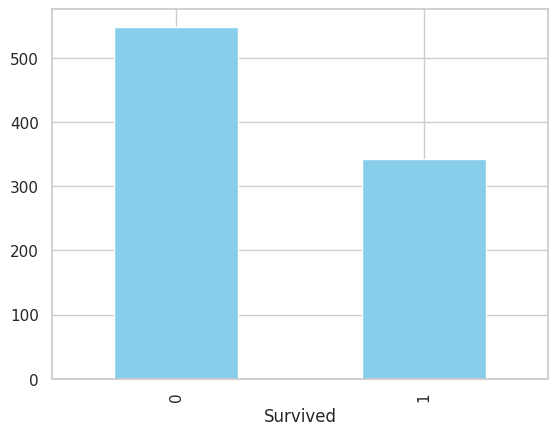

In [11]:
df['Survived'].value_counts().plot(kind='bar',color='skyblue')

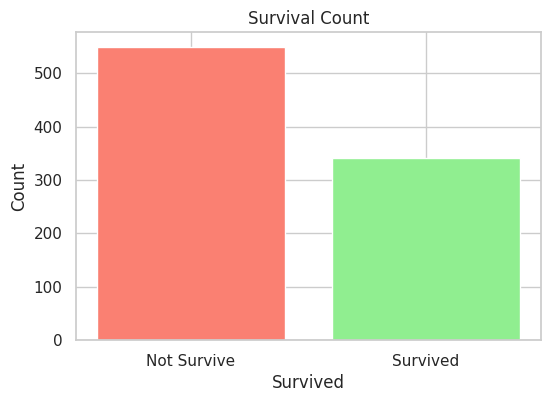

In [12]:
# Using Matplot lib only
import pandas as pd
import matplotlib.pyplot as plt
# Count the number of survived (1) and not survived (0) passengers
survived_counts = df['Survived'].value_counts().sort_index()  # Ensures 0 comes before 1
labels = ['Not Survive', 'Survived']
colors = ['salmon', 'lightgreen']
plt.figure(figsize=(6, 4))
plt.bar(labels, survived_counts, color=colors)
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

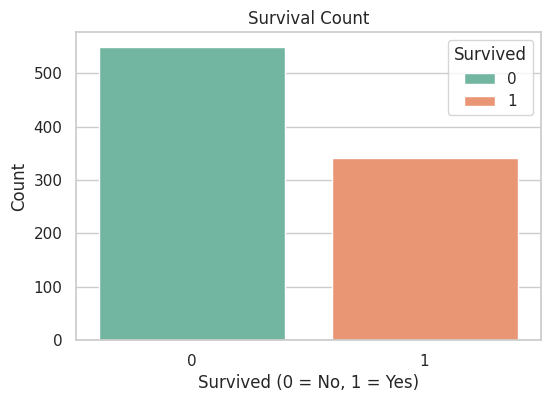

In [13]:
# Count Plot for Survived
# Count the number of survived (1) and not survived (0) passengers
import matplotlib.pyplot as plt
#Topup of matplotlib – Always use seaborn with matplotlib
import seaborn as sns

plt.figure(figsize=(6, 4))
#hue generally use for bivariant
sns.countplot(data=df, x='Survived',palette='Set2', hue='Survived')
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

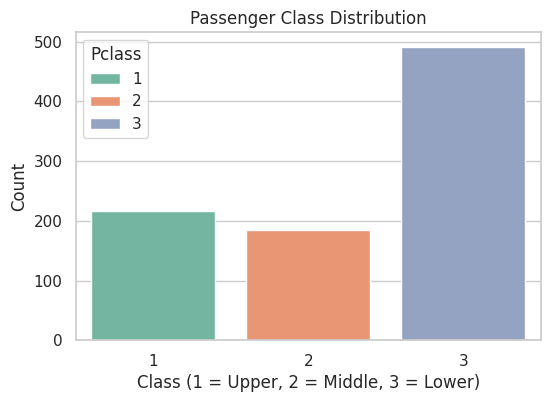

In [14]:
# Count Plot for PClass
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass',palette='Set2', hue='Pclass')
plt.title('Passenger Class Distribution')
plt.xlabel('Class (1 = Upper, 2 = Middle, 3 = Lower)')
plt.ylabel('Count')
plt.show()

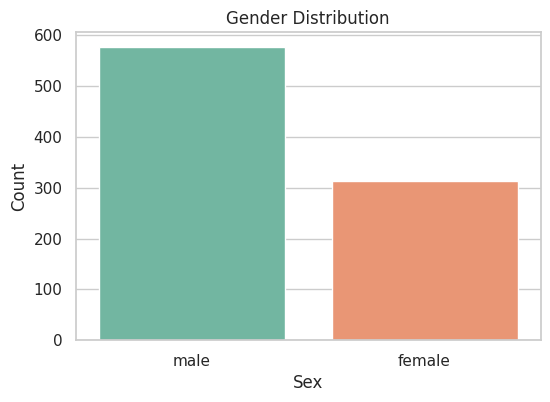

In [15]:
# Count Plot for Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex',palette='Set2', hue='Sex')
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()


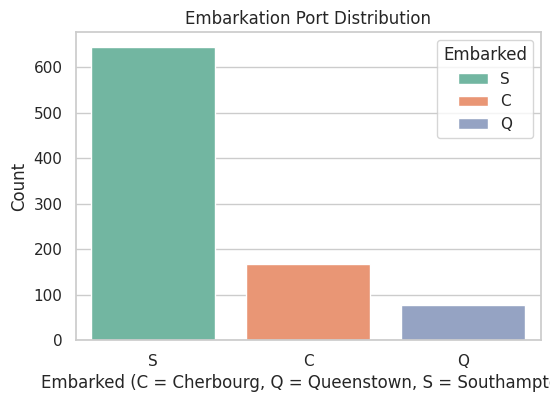

In [16]:
# Count Plot for Embarked distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Embarked',palette='Set2', hue='Embarked')
plt.title('Embarkation Port Distribution')
plt.xlabel('Embarked (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Count')
plt.show()


Pie Chart if Required Data in %

<Axes: ylabel='count'>

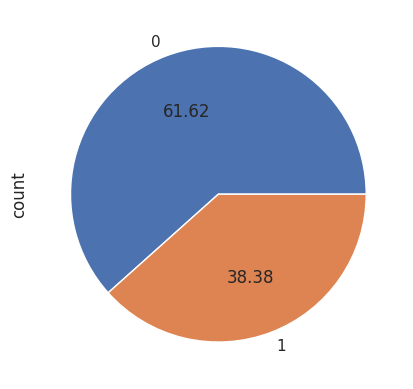

In [17]:
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f') # Survival distribution

<Axes: ylabel='count'>

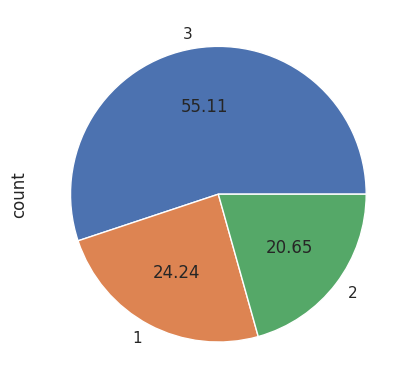

In [18]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f')  # Pessanger class distribution

<Axes: ylabel='count'>

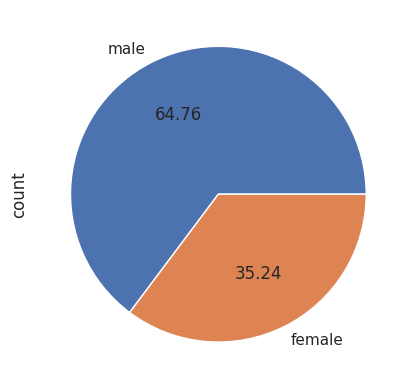

In [19]:
df['Sex'].value_counts().plot(kind='pie',autopct='%.2f') # Gender distribution

--------------------------------------------------------------------
**Analysis of Numerical Data**
Age,Fare,SibSp,Parch

A histogram is a type of bar graph that shows the distribution of a numerical variable by dividing it into intervals (called bins) and counting how many values fall into each bin

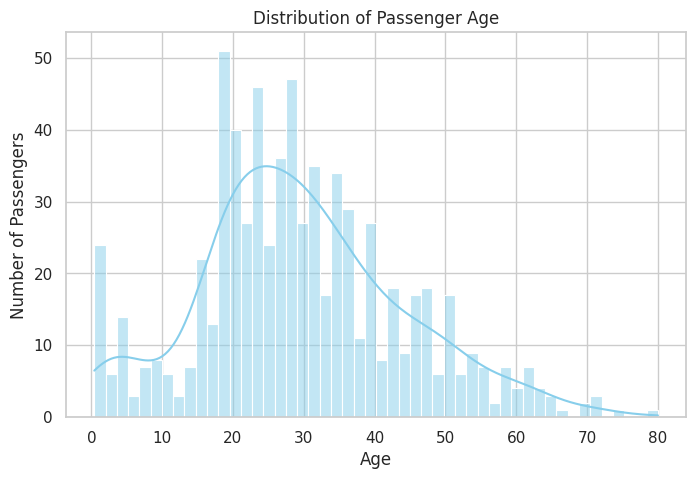

In [20]:
#1. Age — Passenger Age
# Histogram Plot

plt.figure(figsize=(8, 5))
# sns.histplot(df['Age'].dropna(), bins=10, color='skyblue',kde=True)
sns.histplot(df['Age'].dropna(), bins=50, color='skyblue',kde=True)
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()


1. Bins --> A bin is a range like 0–5, 5–10, 10–15...
Each bar shows how many people fall in that bin.
2. Shape of the Distribution -->  The histogram is not symmetric. It’s slightly right-skewed means younger passengers were more common and There are less people above age 60 — short bars to the right.


Some findings based on above histogram
1. What age group had the most passengers?
2. Are there any extreme ages (outliers)?



3. How would you divide bins to better understand children vs adults?
   
0–5 (infants/toddlers) 6–12 (children) 13–18 (teenagers) 19–35 (young adults) 36–50 (middle-aged) 51–70 (senior) 71+ (elderly)

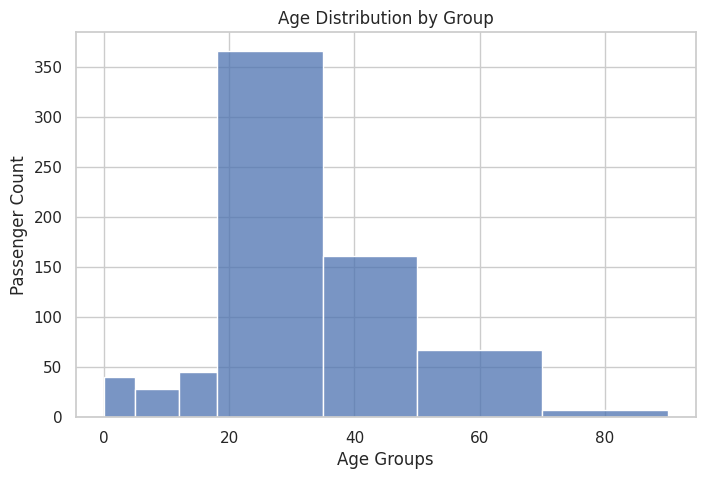

In [21]:
bins = [0, 5, 12, 18, 35, 50, 70, 90]
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=bins, kde=False)
plt.title('Age Distribution by Group')
plt.xlabel('Age Groups')
plt.ylabel('Passenger Count')
plt.show()


Object `plot` not found.


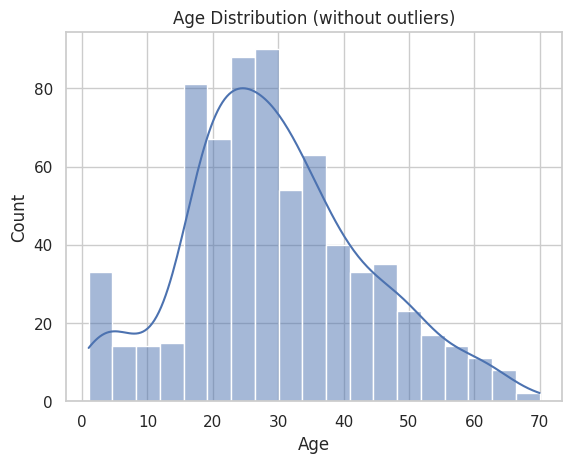

In [22]:
4. What if we remove outliers and re-plot?

age_filtered = df[(df['Age'] >= 1) & (df['Age'] <= 70)]
sns.histplot(age_filtered['Age'], kde=True)
plt.title('Age Distribution (without outliers)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


What is a Boxplot?
A Boxplot is a statistical chart that shows to find potentational outliers and noise
1. The spread of a numerical variable
2. The median, quartiles, and outliers
It’s best graph for detecting:
Skewness
Extreme values (outliers)
Whether the data is tightly packed or widely spread

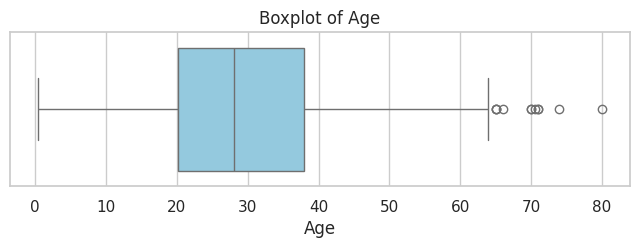

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()



What We Learn From the Plot

1. Median (Middle Line in the Box)
   
 The dark line inside the box is the median age. , On Titanic, median age is around 28–30 years.

2. The Box (Interquartile Range, or IQR)
      Left side = Q1 (25th percentile)
      Right side = Q3 (75th percentile)
      The box shows the middle 50% of the data.
4. Whiskers
Extend from the box to the minimum and maximum values within 1.5 * IQR    (IQR= Q3-Q1)
Shows how spread out the data is
5. Dots Outside = Outliers
Any value beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR is an outlier
These dots represent very young (<1) or very old (>70) passengers

Most passengers are aged between 20 and 40.

In [24]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


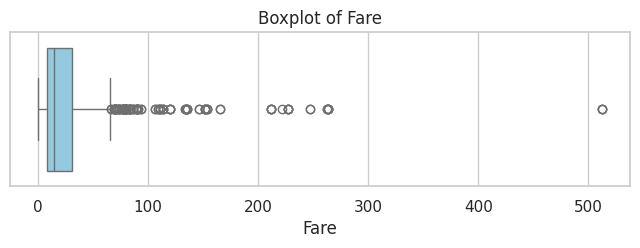

In [25]:
# Box Plot of Fare
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['Fare'], color='skyblue')
plt.title('Boxplot of Fare')
plt.xlabel('Fare')
plt.show()

In [26]:
df['Age'].max()

80.0

In [27]:
df['Age'].min()

0.42

In [28]:
df['Age'].mean()

np.float64(29.69911764705882)

In [29]:
df['Age'].median()

28.0

In [30]:
df['Embarked'].mode()[0]

'S'

In [31]:
df['Age'].skew()    # Age is slightly right-skewed (some old passengers)

np.float64(0.38910778230082704)

In [32]:
df['Fare'].skew()    # Fare is strongly right-skewed (some paid very high fares)


np.float64(4.787316519674893)

/tmp/ipython-input-4190750658.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'],kde=True)


<Axes: xlabel='Age', ylabel='Density'>

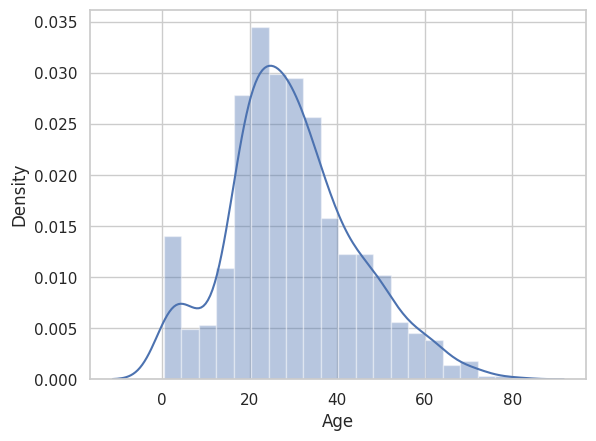

In [35]:
# PDF : Probabilty Density Function
sns.distplot(df['Age'],kde=True)